## Use KNN to classify handwritten digits in MNIST Dataset

In [75]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np

In [76]:
# load mnist dataset
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [77]:
# set x: data and y: target
x, y = mnist["data"], mnist["target"]
print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


In [78]:
# print the first 5 rows of x
x[0:5]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5, 784))

In [79]:
# print the first 12 actual digits
y[0:12]

array(['5', '0', '4', '1', '9', '2', '1', '3', '1', '4', '3', '5'],
      dtype=object)

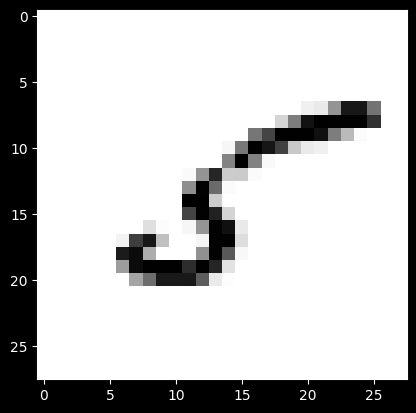

In [80]:
# take data at index 11 in x and plot to show which digit is that
some_digit = x[11]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap='Greys')

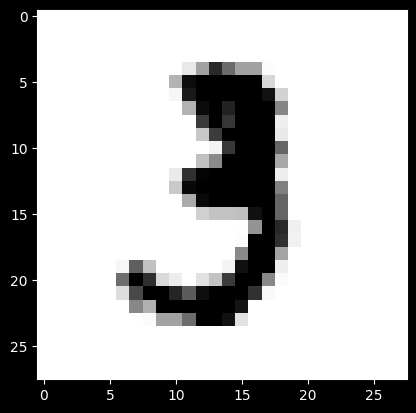

In [81]:
# take data at index 11 in x and plot to show which digit is that
some_digit_2 = x[10]
some_digit_2_image = some_digit_2.reshape(28, 28)
plt.imshow(some_digit_2_image, cmap='Greys')

In [82]:
# function to plot an amount of array with inputs are number of rows and columns
def plot_digits(images_arr, n_rows, n_cols):
    size = 28
    images = [img.reshape(size, size) for img in images_arr]
    row_images = []
    for row in range(n_rows):
        r_images = images[row * n_cols : (row + 1) * n_cols]
        row_images.append(np.concatenate(r_images, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = "Greys",)
    plt.axis("off")

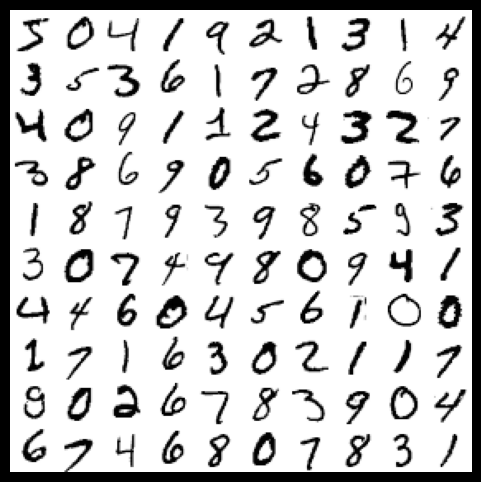

In [83]:
# plot the first 100 digits with number of rows and columns are 10
plt.figure(figsize=(6, 6))
example_images = x[:100]
plot_digits(example_images, n_rows=10, n_cols=10)

In [84]:
# normalize datas using StandardScaler
from sklearn.preprocessing import StandardScaler
x = StandardScaler().fit_transform(x.astype(float))
x[0:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 784))

In [85]:
# Split data x to train and test set in 80/20
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [86]:
# check shape of all sets
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(56000, 784)
(56000,)
(14000, 784)
(14000,)


In [87]:
# start training with KNN with number of neighbors is 4
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

acc = []
k = 4
model = KNeighborsClassifier(n_neighbors=k)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acc.append(accuracy_score(y_test,y_pred))
print('Accuracy with KNN: ', acc)

Accuracy with KNN:  [0.9449285714285715]


In [88]:
# print the first 15 predicted and actual digits
print(y_pred[0:15])
print(y_test[0:15])

['8' '4' '8' '7' '7' '0' '6' '2' '7' '4' '3' '9' '9' '8' '2']
['8' '4' '8' '7' '7' '0' '6' '2' '7' '4' '3' '9' '9' '8' '2']


In [89]:
# take a random digit from data then let model predict
rand_digit = x_test[2222].reshape(1, -1)
model.predict(rand_digit)


array(['0'], dtype=object)

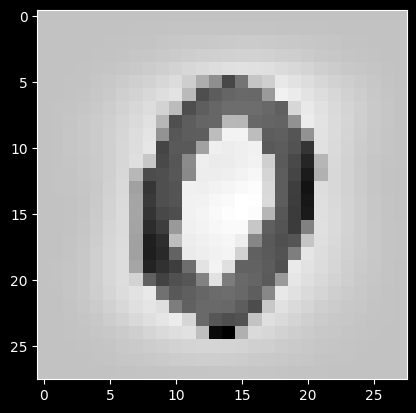

In [90]:
# plot the handwritten digit
rand_digit_image = rand_digit.reshape(28, 28)
plt.imshow(rand_digit_image, cmap='Greys')

In [91]:
# show the probability of each class [0,1,2,3,4,5,6,7,8,9]
model.predict_proba(rand_digit)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])